In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('../../data/house_prices.csv')
X = df.drop('price', axis=1).values
y = df['price'].values

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=64)

In [5]:
mean = np.mean(X_train, axis=0)
std  = np.std(X_train, axis=0)
std[std == 0] = 1
X_train_scaled = (X_train - mean) / std
X_test_scaled  = (X_test  - mean) / std

In [6]:
X_train_b_gd = np.hstack((np.ones((X_train_scaled.shape[0], 1)), X_train_scaled))
X_test_b_gd  = np.hstack((np.ones((X_test_scaled.shape[0],  1)), X_test_scaled))

In [7]:
theta_gd = np.zeros(X_train_b_gd.shape[1])
alpha    = 0.01
epochs   = 1000
n_train  = X_train_b_gd.shape[0]
loss_history = []

In [8]:
for epoch in range(epochs):
    y_pred   = np.dot(X_train_b_gd, theta_gd)
    error    = y_pred - y_train
    gradient = (1/n_train) * np.dot(X_train_b_gd.T, error)
    theta_gd = theta_gd - alpha * gradient
    loss_history.append(np.mean(error**2))

In [9]:
y_train_pred_gd = np.dot(X_train_b_gd, theta_gd)
y_test_pred_gd  = np.dot(X_test_b_gd,  theta_gd)
rmse_train_gd   = root_mean_squared_error(y_train, y_train_pred_gd)
rmse_test_gd    = root_mean_squared_error(y_test,  y_test_pred_gd)
print('Gradient Descent — Train RMSE:', rmse_train_gd)
print('Gradient Descent — Test  RMSE:', rmse_test_gd)

Gradient Descent — Train RMSE: 50403.541579300465
Gradient Descent — Test  RMSE: 47979.863114378524


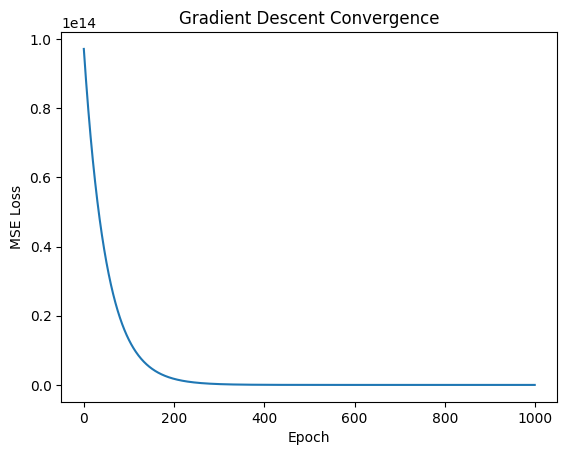

In [13]:
plt.figure()
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Gradient Descent Convergence')
plt.show()